In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
df.shape

(1067371, 8)

In [3]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

# Customer Revenue Prediction

## Data Cleaning and Preprocessing

In [7]:
df.duplicated().sum()

np.int64(34335)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Customer ID"].isnull().sum()

np.int64(235151)

In [11]:
df = df.dropna(subset=["Customer ID"])

In [12]:
df["Customer ID"].isnull().sum()

np.int64(0)

In [13]:
df["Description"].isnull().sum()

np.int64(0)

In [14]:
df["Customer ID"] = df["Customer ID"].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      797885 non-null  object 
 1   StockCode    797885 non-null  object 
 2   Description  797885 non-null  object 
 3   Quantity     797885 non-null  int64  
 4   InvoiceDate  797885 non-null  object 
 5   Price        797885 non-null  float64
 6   Customer ID  797885 non-null  int64  
 7   Country      797885 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 54.8+ MB


In [16]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  int64         
 7   Country      797885 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 54.8+ MB


In [18]:
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

In [19]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,779425.000000,779425,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,145.855814,NaN,29.676140,1695.692775


In [20]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [21]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [22]:
df.shape

(779425, 9)

In [23]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


# Feature Engineering

In this section, we transform the transaction-level dataset into a customer-level dataset. We create meaningful features such as total purchases, total quantity purchased, average order value, and purchase frequency. These features will be used to train the machine learning model for customer revenue prediction.

In [24]:
customer_df = df.groupby("Customer ID").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Average_Price=("Price", "mean"),
    Number_of_Transactions=("Invoice", "nunique"),
    Number_of_Products=("StockCode", "nunique"),
    Average_Quantity=("Quantity", "mean")
).reset_index()

In [25]:
customer_df.head()

,Customer ID,Total_Revenue,Total_Quantity,Average_Price,Number_of_Transactions,Number_of_Products,Average_Quantity
0,12346,77556.46,74285,6.100000,12,27,2184.852941
1,12347,4921.53,2967,2.498063,8,126,13.364865
2,12348,2019.40,2714,3.786275,5,25,53.215686
3,12349,4428.69,1624,8.459657,4,138,9.280000
4,12350,334.40,197,3.841176,1,17,11.588235


In [26]:
customer_df.shape

(5878, 7)

# Exploratory Data Analysis (EDA)

This section explores customer purchasing behaviour through statistical summaries and visualisations. Understanding the data helps identify trends, patterns, and potential issues before training the machine learning model.

## Revenue Distribution

This histogram shows how customer revenue is distributed. It helps determine whether most customers generate low, medium, or high revenue.

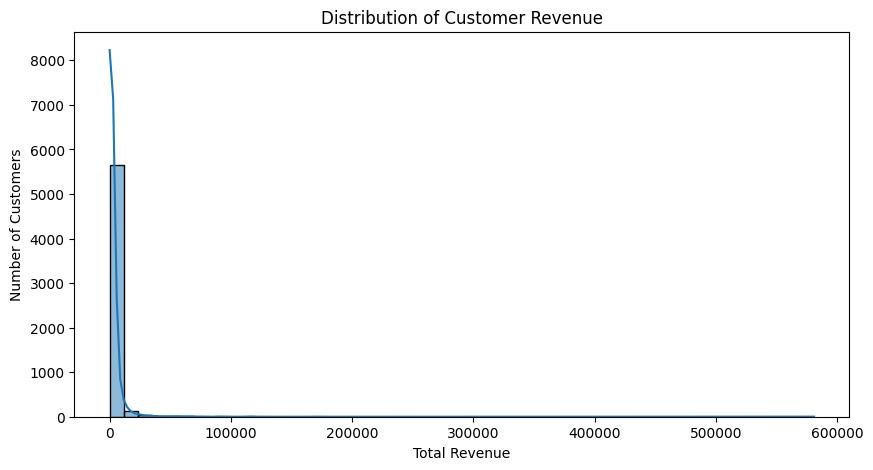

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(customer_df["Total_Revenue"], bins=50, kde=True)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Customers")

plt.show()

## Top 10 Customers by Revenue

This bar chart identifies the top 10 customers who generated the highest revenue. It helps highlight the most valuable customers and their contribution to the business.

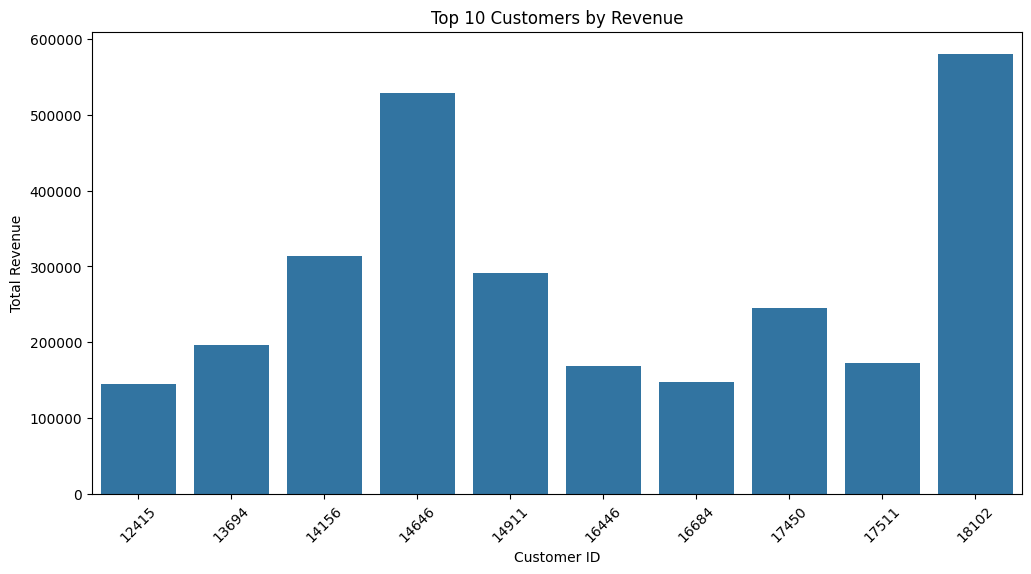

In [28]:
top10 = customer_df.nlargest(10, "Total_Revenue")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Customer ID",
    y="Total_Revenue"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

### Interpretation

The chart highlights the customers who generated the highest revenue. These customers represent the most valuable segment of the business and may be targeted for loyalty programs, personalised offers, or premium services to maximise future revenue.

## Correlation Heatmap

A correlation heatmap is used to measure the relationship between numerical features in the dataset. Correlation values range from -1 to 1, where values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate little or no relationship.

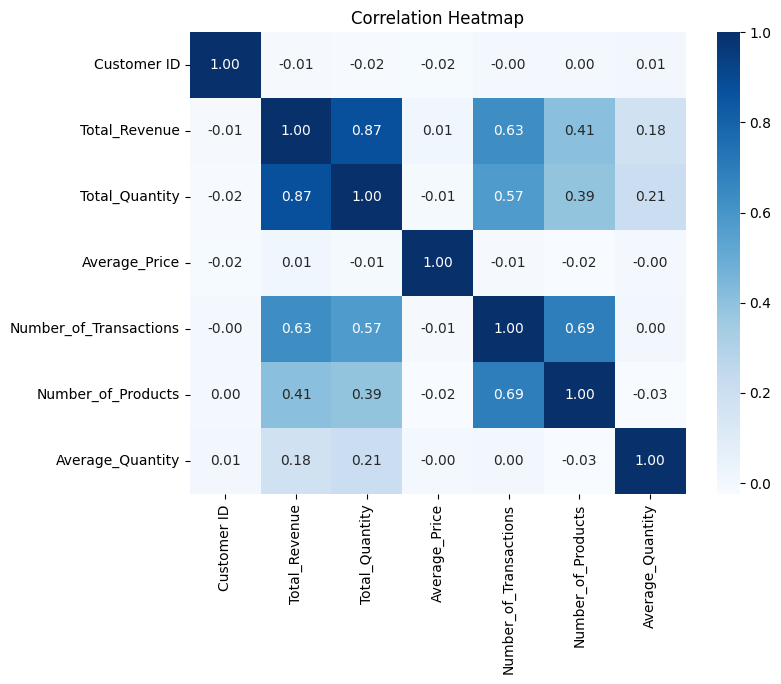

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    customer_df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The heatmap shows the strength of relationships between the numerical features. Features with higher positive correlation to Total Revenue have a greater influence on customer revenue prediction and are useful for training the machine learning model.

## Revenue vs Number of Transactions

This scatter plot illustrates the relationship between the number of transactions made by each customer and their total revenue.

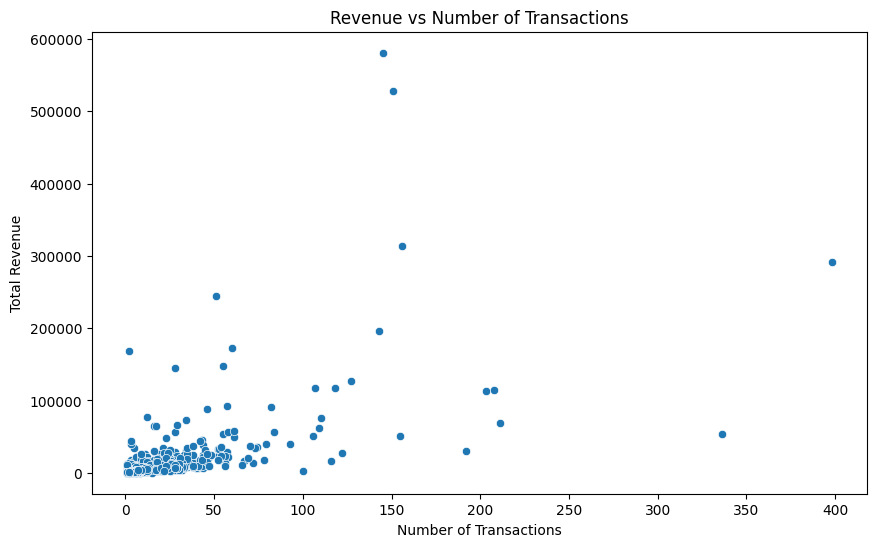

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_df,
    x="Number_of_Transactions",
    y="Total_Revenue"
)

plt.title("Revenue vs Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Revenue")

plt.show()

### Interpretation

The scatter plot indicates whether customers who make more transactions generally generate higher revenue. A positive trend suggests that increasing customer engagement may contribute to increased revenue.

## Revenue vs Quantity Purchased

This scatter plot visualises the relationship between the total quantity of products purchased by each customer and their total revenue.

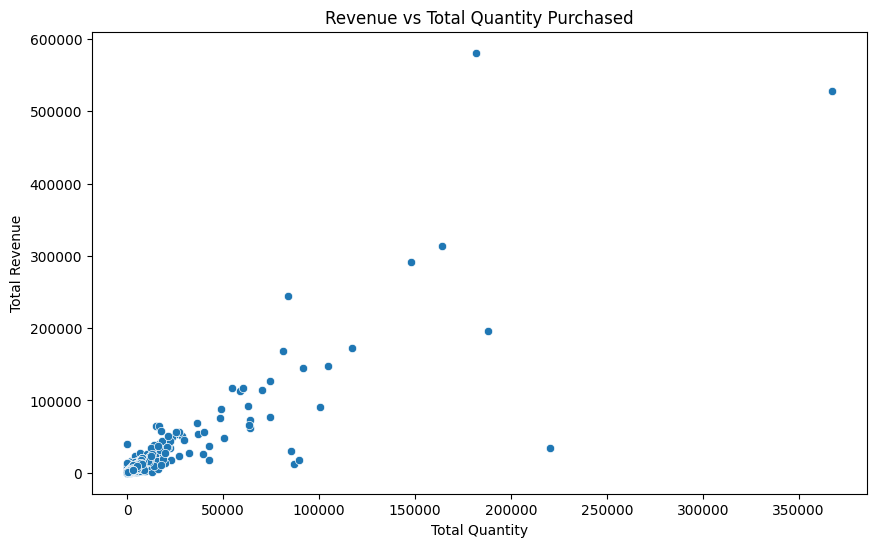

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_df,
    x="Total_Quantity",
    y="Total_Revenue"
)

plt.title("Revenue vs Total Quantity Purchased")
plt.xlabel("Total Quantity")
plt.ylabel("Total Revenue")

plt.show()

### Interpretation

Customers purchasing larger quantities generally contribute more revenue. This relationship helps the machine learning model understand purchasing behaviour and predict future customer revenue more effectively.

## Outlier Detection Using Boxplot

A boxplot is used to detect outliers in customer revenue. Outliers represent customers with exceptionally high or low revenue compared to the majority of customers.

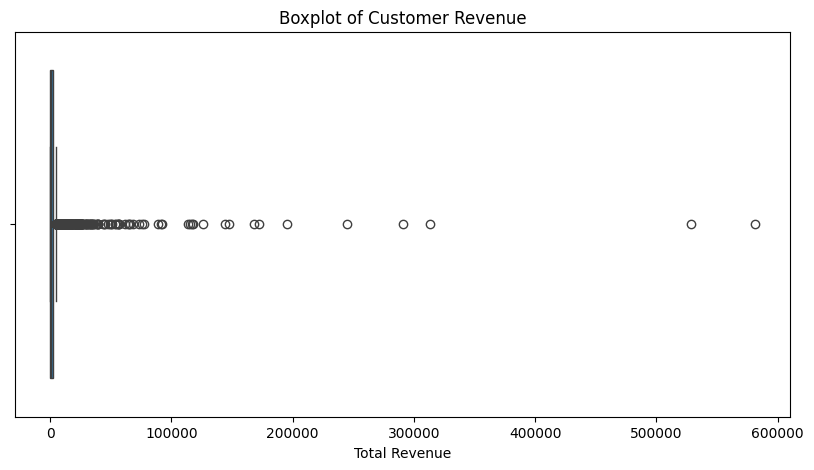

In [32]:
plt.figure(figsize=(10,5))

sns.boxplot(x=customer_df["Total_Revenue"])

plt.title("Boxplot of Customer Revenue")
plt.xlabel("Total Revenue")

plt.show()

### Interpretation

The boxplot reveals the presence of high-value customers whose revenue is significantly greater than the majority of customers. Such outliers are common in retail datasets and often represent loyal or bulk-purchasing customers.

# Machine Learning Model

In this section, machine learning algorithms are trained to predict customer revenue based on customer purchasing behaviour. The dataset is divided into training and testing sets to evaluate the model's performance on unseen data.

## Defining Features and Target Variable

The feature variables (X) contain customer purchasing information, while the target variable (y) represents the total customer revenue that the model aims to predict.

In [33]:
X = customer_df.drop(columns=["Customer ID", "Total_Revenue"])

y = customer_df["Total_Revenue"]

print(X.head())

print(y.head())

   Total_Quantity  Average_Price  Number_of_Transactions  Number_of_Products  \
0           74285       6.100000                      12                  27   
1            2967       2.498063                       8                 126   
2            2714       3.786275                       5                  25   
3            1624       8.459657                       4                 138   
4             197       3.841176                       1                  17   

   Average_Quantity  
0       2184.852941  
1         13.364865  
2         53.215686  
3          9.280000  
4         11.588235  
0    77556.46
1     4921.53
2     2019.40
3     4428.69
4      334.40
Name: Total_Revenue, dtype: float64


## Splitting the Dataset

The dataset is divided into training and testing sets. The training dataset is used to train the machine learning model, while the testing dataset is used to evaluate how well the model performs on unseen data.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (4702, 5)
Testing Samples : (1176, 5)


## Linear Regression Model

Linear Regression is a basic regression algorithm that models the relationship between input features and the target variable using a linear equation. It serves as a baseline model for comparison with more advanced machine learning algorithms.

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 1.09, 1.45,290.04, -6.76, 1.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Total_Quantity','Average_Price','Number_of_Transactions', 'Number_of_Products','Average_Quantity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-345.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [36]:
lr_predictions = lr.predict(X_test)

## Model Evaluation

The performance of the Linear Regression model is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, lr_predictions)

mse = mean_squared_error(y_test, lr_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, lr_predictions)

# Display results
print("=" * 40)
print("Linear Regression Model Evaluation")
print("=" * 40)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Model Evaluation
Mean Absolute Error (MAE): 959.99
Mean Squared Error (MSE): 19704327.57
Root Mean Squared Error (RMSE): 4438.96
R² Score: 0.9457


# Decision Tree Regressor

Decision Tree Regressor is a supervised machine learning algorithm used for regression tasks. It predicts continuous values by recursively splitting the dataset into smaller groups based on feature values. The model learns decision rules from the training data and predicts customer revenue by following these rules.

In [38]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [39]:
dt_predictions = dt_model.predict(X_test)

## Decision Tree Model Evaluation

The performance of the Decision Tree Regressor is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [40]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_mse = mean_squared_error(y_test, dt_predictions)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_predictions)

print("=" * 40)
print("Decision Tree Regressor Evaluation")
print("=" * 40)

print(f"Mean Absolute Error (MAE): {dt_mae:.2f}")
print(f"Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {dt_rmse:.2f}")
print(f"R² Score: {dt_r2:.4f}")

Decision Tree Regressor Evaluation
Mean Absolute Error (MAE): 999.67
Mean Squared Error (MSE): 116779674.53
Root Mean Squared Error (RMSE): 10806.46
R² Score: 0.6784


### Interpretation

The Decision Tree Regressor predicts customer revenue by learning decision rules from the training data. Its performance is evaluated using regression metrics and compared with the Linear Regression model to determine which algorithm performs better for this dataset.

# Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. The final prediction is obtained by averaging the predictions from multiple decision trees.

In [41]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [42]:
# Make predictions
rf_predictions = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


## Random Forest Model Evaluation

The Random Forest Regressor is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [43]:
# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("=" * 40)
print("Random Forest Regressor Evaluation")
print("=" * 40)

print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Regressor Evaluation
Mean Absolute Error (MAE): 656.37
Mean Squared Error (MSE): 57001794.89
Root Mean Squared Error (RMSE): 7549.95
R² Score: 0.8430


# K-Nearest Neighbours (KNN) Regressor

K-Nearest Neighbours (KNN) Regressor is a supervised machine learning algorithm that predicts the target value by averaging the values of the K nearest data points. Similar customers are expected to have similar purchasing behaviour, making KNN suitable for regression problems.

In [44]:
from sklearn.neighbors import KNeighborsRegressor

# Create the model
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN Regressor model trained successfully!")

KNN Regressor model trained successfully!


In [45]:
# Make predictions
knn_predictions = knn_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


## KNN Model Evaluation

The K-Nearest Neighbours Regressor is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [46]:
knn_mae = mean_absolute_error(y_test, knn_predictions)

knn_mse = mean_squared_error(y_test, knn_predictions)

knn_rmse = np.sqrt(knn_mse)

knn_r2 = r2_score(y_test, knn_predictions)

print("=" * 40)
print("KNN Regressor Evaluation")
print("=" * 40)

print(f"Mean Absolute Error (MAE): {knn_mae:.2f}")
print(f"Mean Squared Error (MSE): {knn_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {knn_rmse:.2f}")
print(f"R² Score: {knn_r2:.4f}")

KNN Regressor Evaluation
Mean Absolute Error (MAE): 932.13
Mean Squared Error (MSE): 71649016.14
Root Mean Squared Error (RMSE): 8464.57
R² Score: 0.8027


### Interpretation

The KNN Regressor predicts customer revenue based on the purchasing behaviour of similar customers. Its performance is compared with the other regression models to identify the most suitable algorithm for customer revenue prediction.

# Model Comparison

The performance of all regression models was compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The model with the highest R² Score was selected as the final model for customer revenue prediction.

In [47]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN Regressor"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae,
        knn_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse,
        knn_rmse
    ],
    "R2 Score": [
        r2,
        dt_r2,
        rf_r2,
        knn_r2
    ]
})

comparison.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,959.988783,4438.955684,0.945738
2,Random Forest,656.373694,7549.953304,0.843027
3,KNN Regressor,932.127191,8464.574185,0.802691
1,Decision Tree,999.666343,10806.464479,0.678409


In [48]:
best_model = comparison.iloc[0]

print("=" * 50)
print("Best Model")
print("=" * 50)
print(best_model)

Best Model
Model       Linear Regression
MAE                959.988783
RMSE              4438.955684
R2 Score             0.945738
Name: 0, dtype: object


## Comparison of Machine Learning Models

The following chart compares the R² Scores of all regression models. A higher R² Score indicates better predictive performance.

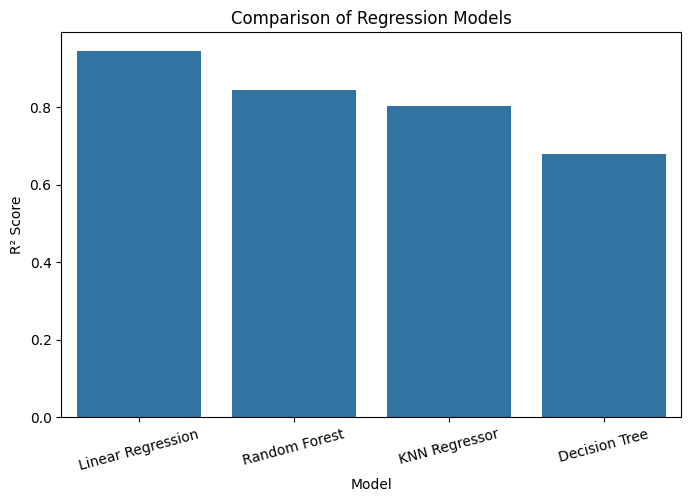

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

In [51]:
import pickle

with open("deployment/linear_regression_model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!


In [52]:
feature_columns = list(X.columns)

with open("deployment/feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

print(feature_columns)
print("Feature columns saved successfully!")

['Total_Quantity', 'Average_Price', 'Number_of_Transactions', 'Number_of_Products', 'Average_Quantity']
Feature columns saved successfully!


# Business Insights

The analysis of the Online Retail II dataset provides several valuable business insights:

- Most customers generate relatively low revenue, while a small percentage of customers contribute significantly higher revenue.
- Customers who make more transactions generally generate higher overall revenue.
- Customers purchasing larger quantities tend to contribute more to total revenue.
- The engineered customer-level features successfully capture purchasing behaviour and improve prediction accuracy.
- Among all the evaluated models, Linear Regression achieved the highest R² Score of **0.9457**, making it the most suitable model for customer revenue prediction on this dataset.

# Business Recommendations

Based on the findings of this project, the following recommendations can help improve business performance:

- Identify high-value customers and reward them through loyalty programs.
- Use personalized marketing campaigns to target customers based on their purchasing behaviour.
- Offer special discounts and promotional offers to frequent customers.
- Monitor customers with declining purchasing activity and introduce re-engagement strategies.
- Use customer revenue predictions to improve marketing decisions and optimize business revenue.

# Limitations

Although the proposed model achieved strong predictive performance, the project has several limitations:

- The model was trained using historical transaction data only.
- Customer demographic information and seasonal trends were not included in the dataset.
- The prediction accuracy depends on the quality and completeness of the available data.
- The model may require retraining as customer purchasing behaviour changes over time.

# Conclusion

This project developed a machine learning system to predict customer revenue using transaction data from an online retail dataset.

The dataset was cleaned, transformed, and aggregated into customer-level features through feature engineering. Exploratory Data Analysis (EDA) was performed to understand customer purchasing behaviour and identify important patterns.

Four regression models were trained and evaluated:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- K-Nearest Neighbours (KNN) Regressor

Among all models, **Linear Regression** achieved the highest R² Score of **0.9457**, indicating the best overall predictive performance on this dataset.

The results demonstrate that customer purchasing behaviour can be effectively used to predict customer revenue, providing valuable insights that can support customer segmentation, marketing strategies, and business decision-making.

# References

1. Online Retail II Dataset
2. Scikit-learn Documentation
3. Pandas Documentation
4. Matplotlib Documentation
5. Seaborn Documentation